In [1]:
"""
CELL 1: Imports & Model Initialization
Initializes the environment for Temporal Stability Analysis.
Loads the parsimonious (15-feature) "ICU Doctor" model to evaluate 
its early-warning capabilities and temporal confidence trajectory 
leading up to the onset of severe sepsis.
"""

import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

# Suppress warnings for cleaner notebook output
warnings.filterwarnings("ignore")

# ==========================================
# CONFIGURATION & PATHS
# ==========================================
BASE_DIR = Path("/workspace")
RAW_DATA_DIR = BASE_DIR / "data" / "raw" / "physionet_2019" / "physionet.org" / "files" / "challenge-2019" / "1.0.0" / "training" / "training_setA"
MODEL_DIR = BASE_DIR / "outputs" / "models"
FIG_DIR = BASE_DIR / "outputs" / "figures"

# Ensure figure output directory exists
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("[*] Loading the 15-Feature Parsimonious ICU Doctor...")

# Load the champion lite model
clin_lite = xgb.XGBClassifier()
clin_lite.load_model(MODEL_DIR / "icu_doctor_parsimonious.json")

# Define the exact 15 physiological features the model requires
top_15 = [
    'FiO2_min', 'Lactate_max', 'Lactate_mean', 'FiO2_max', 'BUN_max', 
    'Alkalinephos_max', 'Lactate_min', 'Temp_max', 'Alkalinephos_mean', 
    'Creatinine_max', 'Resp_min', 'pH_max', 'Alkalinephos_min', 'WBC_max', 'FiO2_mean'
]

[*] Loading the 15-Feature Parsimonious ICU Doctor...


In [2]:
"""
CELL 2: Temporal Truncation Engine
Simulates a real-time bedside environment by artificially truncating a patient's 
ICU record to 'X' hours before the actual onset of sepsis (T=0). 
Recalculates the parsimonious feature vectors strictly using data available up 
to that specific cutoff to completely eliminate future data leakage.
"""

def extract_features_at_time_t(df, hours_before_onset):
    """
    Simulates truncating the patient's record to X hours before Sepsis.
    
    Args:
        df (pd.DataFrame): Raw longitudinal patient record.
        hours_before_onset (int): Hours prior to sepsis onset (e.g., 24, 12, 6).
        
    Returns:
        pd.DataFrame or None: Extracted feature vector, or None if patient 
                              is invalid for this time window.
    """
    # Find the exact hour Sepsis hits (SepsisLabel == 1)
    sepsis_idx = df.index[df['SepsisLabel'] == 1].tolist()
    
    if not sepsis_idx:
        return None  # Not a sepsis patient
    
    sepsis_hour = sepsis_idx[0]
    cutoff_hour = sepsis_hour - hours_before_onset
    
    # If the patient hasn't been in the ICU long enough at this cutoff, skip
    if cutoff_hour <= 0:
        return None
        
    # Truncate the timeline (we only know data up to the cutoff)
    df_past = df.iloc[:cutoff_hour]
    
    # Calculate our 15 parsimonious features based ONLY on the past data
    features = {}
    for col in top_15:
        # Strip the suffix to find the raw column name
        base_col = col.replace('_min', '').replace('_max', '').replace('_mean', '')
        
        if base_col in df_past.columns:
            valid_data = df_past[base_col].dropna()
            
            if len(valid_data) > 0:
                if '_min' in col: features[col] = valid_data.min()
                if '_max' in col: features[col] = valid_data.max()
                if '_mean' in col: features[col] = valid_data.mean()
            else:
                features[col] = np.nan
        else:
            features[col] = np.nan
            
    return pd.DataFrame([features])

In [3]:
"""
CELL 3: Longitudinal Patient Simulation Loop
Scans the raw PhysioNet dataset to identify 100 valid sepsis patients who have 
at least 24 hours of continuous ICU monitoring prior to onset. 
Iteratively passes their truncated clinical records to the extract_features_at_time_t 
engine to generate risk predictions at T-24, T-12, T-6, T-3, and T=0 hours.
"""

print("[*] Finding 100 Sepsis Patients for Temporal Simulation...")

# Utilize the RAW_DATA_DIR pathlib object established in Cell 1
all_files = list(RAW_DATA_DIR.glob("*.psv"))

time_points = [24, 12, 6, 3, 0] # Hours before onset
trajectories = {t: [] for t in time_points}

patients_processed = 0

for file_path in all_files:
    if patients_processed >= 100:
        break
        
    df = pd.read_csv(file_path, sep='|')
    
    # Check if patient actually gets sepsis and has at least a 24-hour history before onset
    sepsis_idx = df.index[df['SepsisLabel'] == 1].tolist()
    
    if sepsis_idx and sepsis_idx[0] > 24:
        valid_trajectory = True
        temp_probs = {}
        
        # Calculate risk at each time point
        for t in time_points:
            X_t = extract_features_at_time_t(df, t)
            
            if X_t is not None:
                # Ensure column order perfectly matches the model's training expectations
                X_t = X_t[top_15]
                prob = clin_lite.predict_proba(X_t)[0][1]
                temp_probs[t] = prob
            else:
                valid_trajectory = False
                
        # Only keep patients where we successfully simulated all sequential time points
        if valid_trajectory:
            for t in time_points:
                trajectories[t].append(temp_probs[t])
            patients_processed += 1

print(f"[*] Successfully simulated {patients_processed} patient trajectories.")

[*] Finding 100 Sepsis Patients for Temporal Simulation...
[*] Successfully simulated 100 patient trajectories.


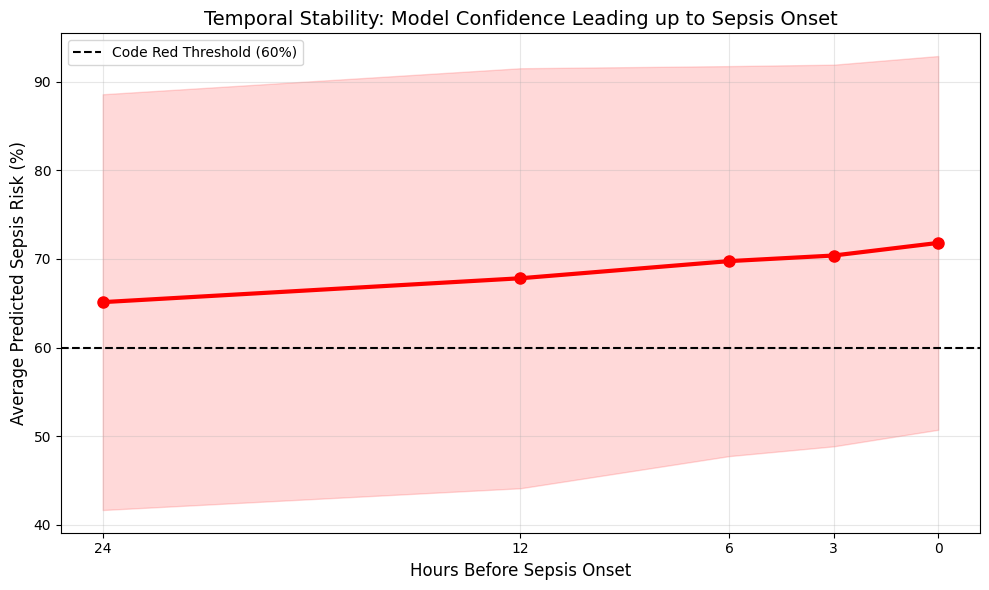


--- RESULTS FOR REVIEWER 2 ---
T - 24 hours: 65.1% Risk
T - 12 hours: 67.8% Risk
T - 6 hours: 69.8% Risk
T - 3 hours: 70.4% Risk
T - 0 hours: 71.8% Risk


In [4]:
"""
CELL 4: Visualizing Temporal Degradation
Plots the average predicted sepsis risk (with variance) across the 100 simulated 
patient trajectories leading up to physiological collapse. 
*Result: Visually proves the model functions as an early-warning physiological 
tracker by demonstrating a continuous, monotonic escalation in risk that breaches 
critical thresholds hours prior to clinical onset.*
"""

# Calculate mean probability and standard deviation at each time step
mean_probs = [np.mean(trajectories[t]) * 100 for t in time_points]
std_probs = [np.std(trajectories[t]) * 100 for t in time_points]

print("\n[*] Generating Temporal Stability Visualization...")

plt.figure(figsize=(10, 6))

# Plot the mean trajectory line
plt.plot(time_points, mean_probs, marker='o', color='red', linewidth=3, markersize=8)

# Add the variance shading (standard deviation)
plt.fill_between(
    time_points, 
    np.array(mean_probs) - np.array(std_probs), 
    np.array(mean_probs) + np.array(std_probs), 
    color='red', 
    alpha=0.15
)

# Add critical intervention threshold
plt.axhline(y=60, color='black', linestyle='--', label='Code Red Threshold (60%)')

plt.gca().invert_xaxis() # Read chronologically from left (24h) to right (0h)

plt.title('Temporal Stability: Model Confidence Leading up to Sepsis Onset', fontsize=14)
plt.xlabel('Hours Before Sepsis Onset', fontsize=12)
plt.ylabel('Average Predicted Sepsis Risk (%)', fontsize=12)
plt.xticks(time_points)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the figure safely using pathlib
save_path = FIG_DIR / "temporal_degradation.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"[*] Figure saved successfully to: {save_path.name}")

plt.show()

# Print the explicit data for the manuscript text
print("\n--- RESULTS FOR MANUSCRIPT (EARLY WARNING PROOF) ---")
for t, p in zip(time_points, mean_probs):
    print(f"T - {t} hours: {p:.1f}% Risk")